c:\Users\taoji\anaconda3\Lib\site-packages\kwant\lattice.py:120: KwantDeprecationWarning:

Not specfying norbs is deprecated. Always specify norbs when creating site families.



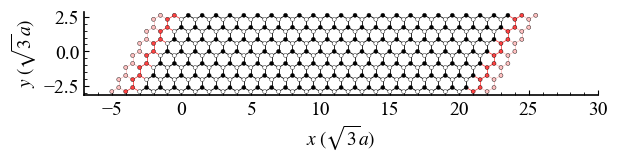

In [17]:
# ============================================================
#  Graphene ribbon with two leads
#  Black & white, PRL style, axis in units of sqrt(3)*a
# ============================================================

import kwant
import numpy as np
import matplotlib.pyplot as plt
import os


# ============================================================
#  1. Global parameters
# ============================================================
t = 1.0
L = 20        # ribbon length (in Kwant coordinates)
W = 3         # half width |y| <= W


# ============================================================
#  2. Output directory
# ============================================================
out_dir = r"D:\结果"
os.makedirs(out_dir, exist_ok=True)


# ============================================================
#  3. Lattice
# ============================================================
graphene = kwant.lattice.honeycomb()
a, b = graphene.sublattices


# ============================================================
#  4. Scattering region
# ============================================================
def ribbon_shape(pos):
    x, y = pos
    return (0 <= x <= L) and (abs(y) <= W)


def make_scattering_region():
    syst = kwant.Builder()
    syst[graphene.shape(ribbon_shape, (0, 0))] = 0.0
    syst[graphene.neighbors()] = -t
    return syst


# ============================================================
#  5. Leads
# ============================================================
def lead_shape(pos):
    x, y = pos
    return abs(y) <= W


def make_leads():
    # left lead
    sym_left = kwant.TranslationalSymmetry((-1, 0))
    lead_left = kwant.Builder(sym_left)
    lead_left[graphene.shape(lead_shape, (0, 0))] = 0.0
    lead_left[graphene.neighbors()] = -t

    # right lead
    sym_right = kwant.TranslationalSymmetry((1, 0))
    lead_right = kwant.Builder(sym_right)
    lead_right[graphene.shape(lead_shape, (0, 0))] = 0.0
    lead_right[graphene.neighbors()] = -t

    return lead_left, lead_right


# ============================================================
#  6. Build full system
# ============================================================
def make_system():
    syst = make_scattering_region()
    lead_left, lead_right = make_leads()
    syst.attach_lead(lead_left)
    syst.attach_lead(lead_right)
    return syst


# ============================================================
#  7. Plot (black & white, centered, PRL style)
# ============================================================
if __name__ == "__main__":

    syst = make_system()

    # --- PRL-like matplotlib style ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",
        "font.size": 14,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
    })

    fig = kwant.plot(
        syst,
        site_color=lambda site: "black" if site.family == a else "white",
        site_edgecolor="black",
        site_lw=0.05,
        hop_color="black",
        hop_lw=0.1,
        show=False
    )

    ax = plt.gca()

    # ========================================================
    #  坐标处理
    # ========================================================

    # 把 x=0 移到散射区中心
    ax.set_xlim(-L*0.7/2, L/2*3)

    # 坐标轴标签（人为规定单位）
    ax.set_xlabel(r"$x\;(\sqrt{3}a)$")
    ax.set_ylabel(r"$y\;(\sqrt{3}a)$")

    # 次刻度
    ax.minorticks_on()

    # 去掉上、右边框（PRL 常见）
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    # ========================================================
    #  保存
    # ========================================================
    fig.savefig(os.path.join(out_dir, "graphene_ribbon_bw.pdf"))
    fig.savefig(os.path.join(out_dir, "graphene_ribbon_bw.png"), dpi=600)

    plt.show()


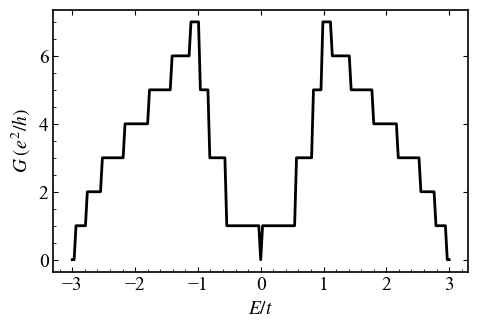

In [20]:
# ============================================================
#  Conductance calculation & save to D:\结果
# ============================================================

fsyst = syst.finalized()

energies = np.linspace(-3, 3, 201)
conductance = []

for E in energies:
    try:
        smatrix = kwant.smatrix(fsyst, energy=E)
        G = smatrix.transmission(1, 0)   # 左导线(0) -> 右导线(1)
    except Exception:
        G = 0.0
    conductance.append(G)

plt.figure(figsize=(5, 3.5))

plt.plot(energies, conductance, lw=2, color="black")

plt.xlabel(r"$E/t$")
plt.ylabel(r"$G\;(e^2/h)$")

plt.minorticks_on()
plt.tick_params(direction="in", top=True, right=True)

plt.tight_layout()

# ===== 强制保存到 D:\结果 =====
plt.savefig(os.path.join(out_dir, "graphene_conductance.pdf"))
plt.savefig(os.path.join(out_dir, "graphene_conductance.png"), dpi=600)

plt.show()
plt.close()


c:\Users\taoji\anaconda3\Lib\site-packages\kwant\lattice.py:120: KwantDeprecationWarning:

Not specfying norbs is deprecated. Always specify norbs when creating site families.



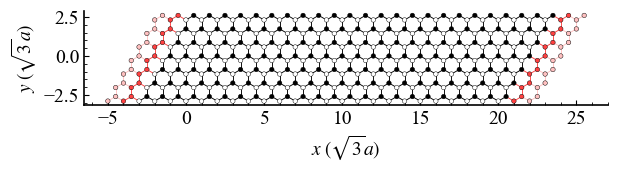

In [49]:
# ============================================================
#  Graphene ribbon with two leads
#  Black & white, PRL style
#  Magnetic field in scattering region: A = (B y, 0, 0)
# ============================================================

import kwant
import numpy as np
import matplotlib.pyplot as plt
import os


# ============================================================
#  1. Global parameters
# ============================================================
t = 1.0
L = 20        # ribbon length (x direction)
W = 3         # half width |y| <= W
B = 0.1      # magnetic field strength (dimensionless)


# ============================================================
#  2. Output directory
# ============================================================
out_dir = r"D:\结果"
os.makedirs(out_dir, exist_ok=True)


# ============================================================
#  3. Lattice
# ============================================================
graphene = kwant.lattice.honeycomb()
a, b = graphene.sublattices


# ============================================================
#  4. Scattering region
# ============================================================
def ribbon_shape(pos):
    x, y = pos
    return (0 <= x <= L) and (abs(y) <= W)


def peierls_hopping(site_i, site_j, B):
    """
    Peierls phase for A = (B y, 0, 0)
    """
    xi, yi = site_i.pos
    xj, yj = site_j.pos
    phase = B * (yi + yj) / 2 * (xj - xi)
    return -t * np.exp(1j * phase)


def make_scattering_region():
    syst = kwant.Builder()

    # onsite
    syst[graphene.shape(ribbon_shape, (0, 0))] = 0.0

    # hopping with magnetic field
    syst[graphene.neighbors()] = peierls_hopping

    return syst


# ============================================================
#  5. Leads (NO magnetic field)
# ============================================================
def lead_shape(pos):
    x, y = pos
    return abs(y) <= W


def make_leads():
    # ---------- left lead ----------
    sym_left = kwant.TranslationalSymmetry((-1, 0))
    lead_left = kwant.Builder(sym_left)
    lead_left[graphene.shape(lead_shape, (0, 0))] = 0.0
    lead_left[graphene.neighbors()] = -t

    # ---------- right lead ----------
    sym_right = kwant.TranslationalSymmetry((1, 0))
    lead_right = kwant.Builder(sym_right)
    lead_right[graphene.shape(lead_shape, (0, 0))] = 0.0
    lead_right[graphene.neighbors()] = -t

    return lead_left, lead_right


# ============================================================
#  6. Build full system
# ============================================================
def make_system():
    syst = make_scattering_region()
    lead_left, lead_right = make_leads()
    syst.attach_lead(lead_left)
    syst.attach_lead(lead_right)
    return syst


# ============================================================
#  7. Plot (PRL style)
# ============================================================
if __name__ == "__main__":

    syst = make_system()

    # --- PRL-like matplotlib style ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",
        "font.size": 14,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
    })

    fig = kwant.plot(
        syst,
        site_color=lambda site: "black" if site.family == a else "white",
        site_edgecolor="black",
        site_lw=0.05,
        hop_color="black",
        hop_lw=0.1,
        show=False
    )

    ax = plt.gca()

    # ========================================================
    #  Axis handling
    # ========================================================
    ax.set_xlabel(r"$x\;(\sqrt{3}a)$")
    ax.set_ylabel(r"$y\;(\sqrt{3}a)$")

    ax.minorticks_on()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    # ========================================================
    #  Save
    # ========================================================
    fig.savefig(os.path.join(out_dir, "graphene_ribbon_Bfield.pdf"))
    fig.savefig(os.path.join(out_dir, "graphene_ribbon_Bfield.png"), dpi=600)

    plt.show()


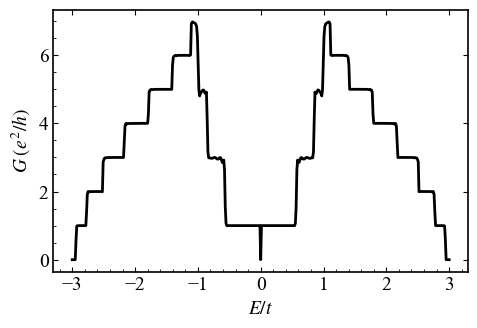

In [52]:
# ============================================================
#  8. Output directory for homework
# ============================================================
out_dir_hw = r"D:\结果\作业"
os.makedirs(out_dir_hw, exist_ok=True)
# ============================================================
#  9. Conductance calculation
# ============================================================

fsyst = syst.finalized()

energies = np.linspace(-3, 3, 501)
conductance = []

for E in energies:
    try:
        smatrix = kwant.smatrix(fsyst, energy=E, params=dict(B=B))
        G = smatrix.transmission(1, 0)   # left -> right
    except Exception:
        G = 0.0
    conductance.append(G)

# ---- plot ----
plt.figure(figsize=(5, 3.5))

plt.plot(energies, conductance, lw=2, color="black")

plt.xlabel(r"$E/t$")
plt.ylabel(r"$G\;(e^2/h)$")

plt.minorticks_on()
plt.tick_params(direction="in", top=True, right=True)

plt.tight_layout()

plt.savefig(os.path.join(out_dir_hw, "graphene_conductance_Bfield.pdf"))
plt.savefig(os.path.join(out_dir_hw, "graphene_conductance_Bfield.png"), dpi=600)

plt.show()



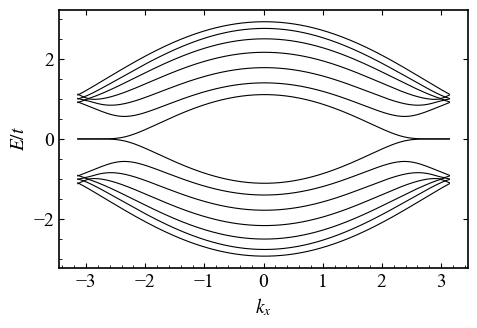

In [51]:
# ============================================================
#  10. Infinite ribbon (band structure)
# ============================================================

def make_infinite_ribbon():
    sym = kwant.TranslationalSymmetry((1, 0))
    syst = kwant.Builder(sym)

    syst[graphene.shape(lead_shape, (0, 0))] = 0.0
    syst[graphene.neighbors()] = peierls_hopping

    return syst.finalized()
# ============================================================
#  11. Band structure
# ============================================================

inf_syst = make_infinite_ribbon()

bands = kwant.physics.Bands(inf_syst, params=dict(B=B))

k_vals = np.linspace(-np.pi, np.pi, 401)
energies_bands = [bands(k) for k in k_vals]

# ---- plot ----
plt.figure(figsize=(5, 3.5))

for n in range(len(energies_bands[0])):
    plt.plot(k_vals, [e[n] for e in energies_bands],
             color="black", lw=0.8)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$E/t$")

plt.minorticks_on()
plt.tick_params(direction="in", top=True, right=True)

plt.tight_layout()

plt.savefig(os.path.join(out_dir_hw, "graphene_band_Bfield.pdf"))
plt.savefig(os.path.join(out_dir_hw, "graphene_band_Bfield.png"), dpi=600)

plt.show()



<Figure size 500x400 with 0 Axes>

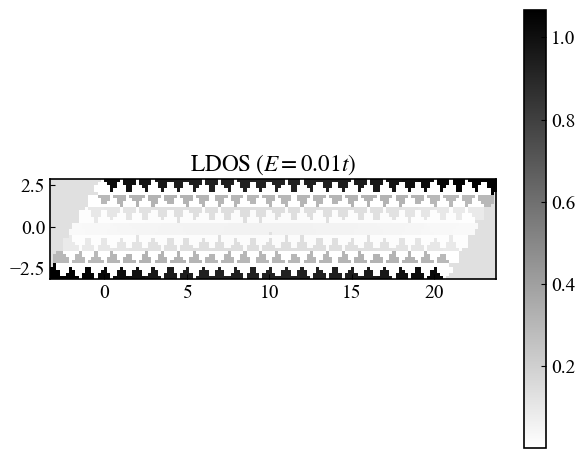

In [58]:
# ============================================================
#  Local density of states (LDOS)
# ============================================================

energy_ldos = 0.01   # 可以换成朗道能级附近

ldos = kwant.ldos(fsyst, energy=energy_ldos, params=dict(B=B))

plt.figure(figsize=(5, 4))
kwant.plotter.map(
    fsyst,
    ldos,
    colorbar=True,
    cmap="gray_r",
    show=False
)

plt.title(r"$\mathrm{LDOS}\;(E=%.2f t)$" % energy_ldos)

plt.tight_layout()
plt.savefig(os.path.join(out_dir_hw, "ldos_B.pdf"))
plt.savefig(os.path.join(out_dir_hw, "ldos_B.png"), dpi=600)
plt.show()
